In [ ]:
# Libs/Frameworks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xlsxwriter

In [ ]:
file_name = '/content/Metadata Quality (Season vs. Parent).xlsx'


In [ ]:
df_mood = pd.read_excel(file_name, sheet_name="Mood")

df_mood['Status'].value_counts()

,count
Status,
BOTH_PROGRAM_AND_SEASON_FILLED,2624
BOTH_PROGRAM_AND_SEASON_MISSING,533
PROGRAM_MISSING_BUT_SEASON_FILLED,404
PROGRAM_FILLED_BUT_SEASON_MISSING,114


In [ ]:
df_mood_candidates = df_mood[df_mood['Status'] == 'PROGRAM_MISSING_BUT_SEASON_FILLED'].copy()

In [ ]:
distinct_moods = (df_mood_candidates
                  .groupby('Program Id')['Season Mood Values']
                  .nunique()
                  .reset_index(name='n_distinct_season_mood_strings'))

In [ ]:
safe_program_ids = distinct_moods.loc[
    distinct_moods['n_distinct_season_mood_strings'] == 1, 'Program Id'
]

df_safe = df_mood_candidates[df_mood_candidates['Program Id'].isin(safe_program_ids)]

proposed_moods = (df_safe
                  .groupby(['Program Id', 'Program Title'])['Season Mood Values']
                  .first()
                  .reset_index(name='Proposed Program Mood'))

In [ ]:
proposed_moods

,Program Id,Program Title,Proposed Program Mood
0,48990,Jar Al Amar,"Devious, Emotional, Sad"
1,69039,Hajr Al Habib,"Emotional, Sad"
2,69053,LAW BAQY LAILA,"Emotional, Sad"
3,69083,Hibr El Ouyoun,"Devious, Mischievous, Sad"
4,69147,Ghareeb Al Dar,"Emotional, Impassive"
...,...,...,...
311,49923727507880,The Mosalsal Look By Charles & Keith,Lighthearted
312,49923743368429,Tafa'al,Peaceful
313,49923743415126,El Mir'ah,Enlightening
314,49923743660445,Dorohedoro,"Chaotic, Dark"


In [ ]:
configs = [
    # Mood
    {
        'sheet_name': 'Mood',
        'field_name': 'Mood',
        'program_count_col': 'Program Mood Count',
        'program_value_col': 'Program Mood Values',
        'season_count_col': 'Season Mood Count',
        'season_value_col': 'Season Mood Values',
    },

    # Set_location
    {
        'sheet_name': 'Set Location',
        'field_name': 'Set_location',
        'program_count_col': 'Program Set_location Count',
        'program_value_col': 'Program Set_location Values',
        'season_count_col': 'Season Set_location Count',
        'season_value_col': 'Season Set_location Values',
    },

    # Dialect
    {
        'sheet_name': 'Dialect',
        'field_name': 'Dialect',
        'program_count_col': 'Program Dialect Count',
        'program_value_col': 'Program Dialect Values',
        'season_count_col': 'Season Dialect Count',
        'season_value_col': 'Season Dialect Values',
    },

    # Genre
    {
        'sheet_name': 'Genre',
        'field_name': 'Genre',
        'program_count_col': 'Program Genre Count',
        'program_value_col': 'Program Genre Values',
        'season_count_col': 'Season Genre Count',
        'season_value_col': 'Season Genre Values',
    },

    # Theme
    {
        'sheet_name': 'Theme',
        'field_name': 'Theme',
        'program_count_col': 'Program Theme Count',
        'program_value_col': 'Program Theme Values',
        'season_count_col': 'Season Theme Count',
        'season_value_col': 'Season Theme Values',
    },

    # Relation
    {
        'sheet_name': 'Relation',
        'field_name': 'Relation',
        'program_count_col': 'Program Relation Count',
        'program_value_col': 'Program Relation Values',
        'season_count_col': 'Season Relation Count',
        'season_value_col': 'Season Relation Values',
    },

    # Era
    {
        'sheet_name': 'Era',
        'field_name': 'Era',
        'program_count_col': 'Program Era Count',
        'program_value_col': 'Program Era Values',
        'season_count_col': 'Season Era Count',
        'season_value_col': 'Season Era Values',
    },

    # Plot
    {
        'sheet_name': 'Plot',
        'field_name': 'Plot',
        'program_count_col': 'Program Plot Count',
        'program_value_col': 'Program Plot Values',
        'season_count_col': 'Season Plot Count',
        'season_value_col': 'Season Plot Values',
    },
]

## Helper Functions


In [ ]:
import pandas as pd


def normalize_keys(df):
    for col in ['Program Id', 'Program Title', 'Season Id', 'Season Title']:
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df




def build_inheritance_for_field(
    df,
    field_name,
    program_count_col,
    program_value_col,
    season_count_col,
    season_value_col,
    status_col='Status'
):
    # 0) Normalize value columns to string (keep df copy)
    df = df.copy()
    df[program_value_col] = df[program_value_col].astype(str)
    df[season_value_col] = df[season_value_col].astype(str)

    # 1) Define candidate rows: parent missing, season present (by COUNT)
    mask_program_missing = df[program_count_col].fillna(0) == 0
    mask_season_present = df[season_count_col].fillna(0) > 0
    df_candidates = df[mask_program_missing & mask_season_present].copy()

    # Helper: clean season values (remove 'nan' and empty strings)
    def clean_values(series):
        vals = [v.strip() for v in series if isinstance(v, str)]
        vals = [v for v in vals if v and v.lower() != 'nan']
        return vals

    # 2) For candidates, collect cleaned season values per Program
    vals_per_program = (
        df_candidates
        .groupby('Program Id')[season_value_col]
        .agg(clean_values)
        .reset_index(name='season_values_list')
    )

    # Count distinct cleaned values for each Program
    vals_per_program['n_distinct'] = vals_per_program['season_values_list'].apply(
        lambda lst: len(set(lst))
    )

    # 3) Identify SAFE and REVIEW program ids
    # SAFE: at least one non-null value and all identical
    safe_ids = vals_per_program.loc[
        (vals_per_program['n_distinct'] == 1) &
        (vals_per_program['season_values_list'].apply(len) > 0),
        'Program Id'
    ]

    # REVIEW: more than one distinct cleaned value
    review_ids = vals_per_program.loc[
        vals_per_program['n_distinct'] > 1,
        'Program Id'
    ]

    # 4) Build SAFE proposals from candidates only
    df_safe = df_candidates[df_candidates['Program Id'].isin(safe_ids)].copy()

    def get_single_clean_value(series):
        cleaned = clean_values(series)
        if not cleaned:
            return None
        return list(set(cleaned))[0]

    proposed = (
        df_safe
        .groupby(['Program Id', 'Program Title'])[season_value_col]
        .agg(get_single_clean_value)
        .reset_index(name=f'Proposed_Program_{field_name}')
    )
    proposed[f'Inheritance_Status_{field_name}'] = 'SAFE'

    # 5) Build REVIEW info (optional, for debugging/reporting)
    df_review = df_candidates[df_candidates['Program Id'].isin(review_ids)].copy()

    review = (
        df_review
        .groupby(['Program Id', 'Program Title'])[season_value_col]
        .agg(clean_values)
        .reset_index(name=f'Conflicting_Season_{field_name}_Values')
    )
    review[f'Inheritance_Status_{field_name}'] = 'REVIEW'
    review[f'Proposed_Program_{field_name}'] = None

    # 6) Combine program-level SAFE + REVIEW info
    program_level = pd.concat(
        [
            proposed[['Program Id', 'Program Title',
                      f'Inheritance_Status_{field_name}',
                      f'Proposed_Program_{field_name}']],
            review[['Program Id', 'Program Title',
                    f'Inheritance_Status_{field_name}',
                    f'Proposed_Program_{field_name}']]
        ],
        ignore_index=True
    )

    # 7) Merge back with full df (program-level status)
    df_updated = df.merge(
        program_level,
        on=['Program Id', 'Program Title'],
        how='left'
    )

    status_col_name = f'Inheritance_Status_{field_name}'
    proposed_col_name = f'Proposed_Program_{field_name}'

    df_updated[status_col_name] = df_updated[status_col_name].fillna('NONE')

    # 8) Row-level correction:
    # SAFE/REVIEW only allowed on true candidate rows (parent missing, season present)
    row_mask_program_missing = df_updated[program_count_col].fillna(0) == 0
    row_mask_season_present = df_updated[season_count_col].fillna(0) > 0
    row_is_candidate = row_mask_program_missing & row_mask_season_present

    # Any non-candidate row must not keep SAFE/REVIEW
    df_updated.loc[~row_is_candidate & (df_updated[status_col_name] == 'SAFE'),
                   status_col_name] = 'NONE'
    df_updated.loc[~row_is_candidate & (df_updated[status_col_name] == 'SAFE'),
                   proposed_col_name] = None

    df_updated.loc[~row_is_candidate & (df_updated[status_col_name] == 'REVIEW'),
                   status_col_name] = 'NONE'

    # 9) Metrics at program level
    metrics = {
        'field': field_name,
        'candidate_rows': df_candidates.shape[0],
        'safe_programs': safe_ids.nunique(),
        'review_programs': review_ids.nunique()
    }

    return df_updated, metrics

def normalize_field_types(df, program_count_col, season_count_col):
    # Keys as strings
    for col in ['Program Id', 'Program Title', 'Season Id', 'Season Title', 'Status']:
        if col in df.columns:
            df[col] = df[col].astype(str)

    # Counts as numbers
    for col in [program_count_col, season_count_col]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')  # float or int is fine

    return df


In [ ]:
import pandas as pd

def compute_completeness_for_field(
    csv_path,
    field_name,
    program_count_col,
    inheritance_status_col
):
    df = pd.read_csv(csv_path)

    # Work at program level (one row per Program Id)
    program_level = (
        df.groupby(['Program Id', 'Program Title'])
        .agg({
            program_count_col: 'max',           # if any season shows non-zero, parent considered filled
            inheritance_status_col: lambda x: (x == 'SAFE').any()
        })
        .reset_index()
    )

    # Rename boolean column for clarity
    program_level.rename(
        columns={inheritance_status_col: 'has_safe_inheritance'},
        inplace=True
    )

    # Before: parent missing if Program Count == 0 or NaN
    parent_missing_before = (
        (program_level[program_count_col].fillna(0) == 0)
        .sum()
    )

    # Among missing before, how many have SAFE inheritance proposal
    missing_mask = program_level[program_count_col].fillna(0) == 0
    parent_fixed_by_inheritance = (
        program_level[missing_mask]['has_safe_inheritance']
        .sum()
    )

    remaining_missing_after = parent_missing_before - parent_fixed_by_inheritance

    return {
        'field': field_name,
        'parent_missing_before': int(parent_missing_before),
        'parent_fixed_by_inheritance': int(parent_fixed_by_inheritance),
        'parent_remaining_missing_after': int(remaining_missing_after),
    }

In [ ]:
import pandas as pd

excel_path = "/content/Metadata Quality (Season vs. Parent).xlsx"  # original file

all_metrics = []
updated_sheets = {}  # sheet_name -> df_updated

for cfg in configs:
    print("\n=== Processing sheet:", cfg['sheet_name'], "field:", cfg['field_name'], "===")
    df_sheet = pd.read_excel(excel_path, sheet_name=cfg['sheet_name'])

    df_sheet = normalize_field_types(
        df_sheet,
        program_count_col=cfg['program_count_col'],
        season_count_col=cfg['season_count_col']
    )

    print(df_sheet.dtypes)

    df_updated, metrics = build_inheritance_for_field(
        df=df_sheet,
        field_name=cfg['field_name'],
        program_count_col=cfg['program_count_col'],
        program_value_col=cfg['program_value_col'],
        season_count_col=cfg['season_count_col'],
        season_value_col=cfg['season_value_col'],
    )

    # store updated sheet in memory instead of CSV
    updated_sheets[cfg['sheet_name']] = df_updated

    all_metrics.append(metrics)
    print(f"Processed {cfg['field_name']}")

# ---- build metrics df ----
metrics_df = pd.DataFrame(all_metrics)
metrics_df['safe_rate'] = metrics_df['safe_programs'] / metrics_df['candidate_rows']
metrics_df['review_rate'] = metrics_df['review_programs'] / metrics_df['candidate_rows']

# ---- write a single Excel with multiple sheets ----
output_excel = "Metadata_Season_vs_Parent_with_inheritance_proposals.xlsx"

with pd.ExcelWriter(output_excel, engine="xlsxwriter") as writer:
    # 1) updated per-field sheets
    for sheet_name, df_updated in updated_sheets.items():
        df_updated.to_excel(writer, sheet_name=sheet_name, index=False)

    # 2) metrics sheet
    metrics_df.to_excel(writer, sheet_name="Inheritance_Metrics", index=False)

print("Saved combined review workbook to:", output_excel)
metrics_df


=== Processing sheet: Mood field: Mood ===
Program Id             object
Program Title          object
Program Mood Count      int64
Program Mood Values    object
Season Id              object
Season Title           object
Season Mood Count       int64
Season Mood Values     object
Status                 object
dtype: object
Processed Mood

=== Processing sheet: Set Location field: Set_location ===
Program Id                     object
Program Title                  object
Program Set_location Count      int64
Program Set_location Values    object
Season Id                      object
Season Title                   object
Season Set_location Count       int64
Season Set_location Values     object
Status                         object
dtype: object
Processed Set_location

=== Processing sheet: Dialect field: Dialect ===
Program Id                object
Program Title             object
Program Dialect Count      int64
Program Dialect Values    object
Season Id                 object
Sea

,field,candidate_rows,safe_programs,review_programs,safe_rate,review_rate
0,Mood,404,316,18,0.782178,0.044554
1,Set_location,687,521,37,0.758370,0.053857
2,Dialect,1448,1024,24,0.707182,0.016575
3,Genre,150,72,13,0.480000,0.086667
4,Theme,380,174,17,0.457895,0.044737
5,Relation,214,167,14,0.780374,0.065421
6,Era,453,350,15,0.772627,0.033113
7,Plot,488,395,14,0.809426,0.028689


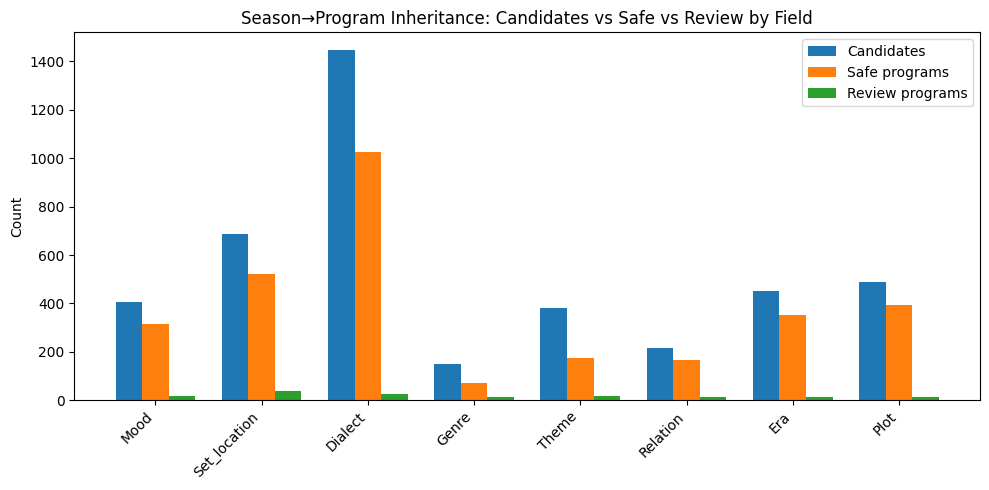

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fields = metrics_df['field']
x = np.arange(len(fields))

width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width, metrics_df['candidate_rows'], width, label='Candidates')
ax.bar(x,         metrics_df['safe_programs'],  width, label='Safe programs')
ax.bar(x + width, metrics_df['review_programs'],width, label='Review programs')

ax.set_xticks(x)
ax.set_xticklabels(fields, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Season→Program Inheritance: Candidates vs Safe vs Review by Field')
ax.legend()

plt.tight_layout()
plt.savefig("inheritance_metrics_by_field.png", dpi=200)
plt.show()

In [ ]:
import pandas as pd

OUTPUT_EXCEL = "Metadata_Season_vs_Parent_with_inheritance_proposals.xlsx"

fields_config = [
    ("Mood",         "Program Mood Count",         "Inheritance_Status_Mood"),
    ("Set Location", "Program Set_location Count", "Inheritance_Status_Set_location"),
    ("Dialect",      "Program Dialect Count",      "Inheritance_Status_Dialect"),
    ("Genre",        "Program Genre Count",        "Inheritance_Status_Genre"),
    ("Theme",        "Program Theme Count",        "Inheritance_Status_Theme"),
    ("Relation",     "Program Relation Count",     "Inheritance_Status_Relation"),
    ("Era",          "Program Era Count",          "Inheritance_Status_Era"),
    ("Plot",         "Program Plot Count",         "Inheritance_Status_Plot"),
]

rows = []

for field_name, program_count_col, status_col in fields_config:
    df = pd.read_excel(OUTPUT_EXCEL, sheet_name=field_name)

    # program-level view
    prog = (
        df.groupby("Program Id")
          .agg({
              program_count_col: "max",
              status_col: lambda s: (s == "SAFE").any()
          })
          .reset_index()
          .rename(columns={status_col: "has_safe"})
    )

    missing_before = (prog[program_count_col].fillna(0) == 0).sum()

    missing_mask = prog[program_count_col].fillna(0) == 0
    fixed_by_safe = prog[missing_mask]["has_safe"].sum()

    missing_after = missing_before - fixed_by_safe

    rows.append({
        "field": field_name,
        "parent_missing_before": int(missing_before),
        "parent_remaining_missing_after": int(missing_after),
    })

completeness_df = pd.DataFrame(rows)
completeness_df.to_csv("inheritance_before_after_completeness.csv", index=False)

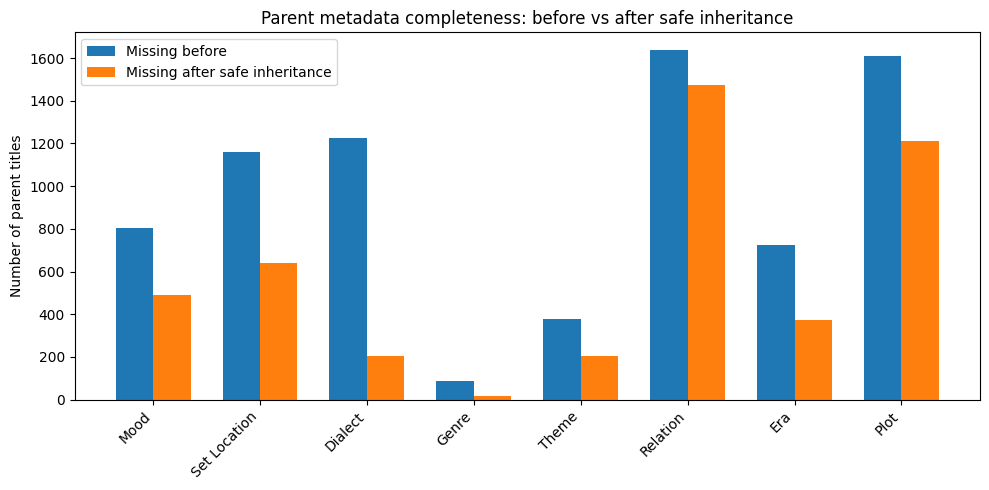

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fields = completeness_df['field']
x = np.arange(len(fields))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width/2, completeness_df['parent_missing_before'],
       width, label='Missing before')
ax.bar(x + width/2, completeness_df['parent_remaining_missing_after'],
       width, label='Missing after safe inheritance')

ax.set_xticks(x)
ax.set_xticklabels(fields, rotation=45, ha='right')
ax.set_ylabel('Number of parent titles')
ax.set_title('Parent metadata completeness: before vs after safe inheritance')
ax.legend()

plt.tight_layout()
plt.savefig("parent_completeness_before_after.png", dpi=200)
plt.show()